In [10]:
!pip install spacy torchtext

# Download German and English models
!python -m spacy download de_core_news_sm
!python -m spacy download en_core_web_sm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.0/31.0 MB 73.5 MB/s  0:00:006m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.3/780.3 kB 28.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 50.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 63.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 70.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 11.7 MB/s  0:00:00
  Attempting uninstall: typing-extensions━━━━━━━━━━━━━━━━━━━━━━━━━  1/24 [wasabi]
    Found existing installation: typing_extensions 4.12.2━━━━━  1/24 [wasabi]
    Uninstalling typing_extensions-4.12.2:━━━━━━━━━━━━━━━━━━━━  1/24 [wasabi]
      Successfully uninstalled typing_extensions-4.12.2━━━━━━━━━━━  2/24 [typing-extensions]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24/24 [spacy]m23/24 [spacy]]c]]ib]]s]s]

[notice] A new release of pip is available: 

In [11]:
import math
import time

import torch
import torch.nn as nn
import torch.optim as optim

from tqdm import tqdm


In [12]:
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    """
    Implements the Multi-Head Attention mechanism from 'Attention Is All You Need'.
    """

    def __init__(self, d_model: int, h: int):
        super().__init__()
        assert d_model % h == 0, "d_model must be divisible by h"

        self.d_model = d_model
        self.h = h
        self.d_k = d_model // h

        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, q, k, v, mask=None):
        d_k = q.size(-1)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

        if mask is not None:
            # mask == 0 are the positions we want to mask out
            scores = scores.masked_fill(mask == 0, -1e9)

        attention_weights = F.softmax(scores, dim=-1)
        output = torch.matmul(attention_weights, v)
        return output, attention_weights

    def forward(self, q: torch.Tensor, k: torch.Tensor, v: torch.Tensor, mask: torch.Tensor = None) -> torch.Tensor:
        batch_size = q.size(0)

        # Linear projections
        q = self.w_q(q).view(batch_size, -1, self.h, self.d_k).transpose(1, 2)
        k = self.w_k(k).view(batch_size, -1, self.h, self.d_k).transpose(1, 2)
        v = self.w_v(v).view(batch_size, -1, self.h, self.d_k).transpose(1, 2)

        # Apply scaled dot-product attention
        x, _ = self.scaled_dot_product_attention(q, k, v, mask=mask)

        # Concatenate heads
        x = x.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

        return self.w_o(x)


In [13]:
class PositionWiseFeedForward(nn.Module):
    """
    Position-wise Feed-Forward Network (FFN).
    FFN(x) = max(0, xW1 + b1)W2 + b2
    """

    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.linear1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.linear2(x)
        return x


In [14]:
class PositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding as in 'Attention Is All You Need'.
    """

    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))

        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)

        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


In [15]:
def create_masks(src: torch.Tensor, trg: torch.Tensor, pad_idx: int):
    """
    Creates source and target masks.
    src: (batch, src_len)
    trg: (batch, trg_len)
    """
    # Source padding mask: (batch, 1, 1, src_len)
    src_mask = (src != pad_idx).unsqueeze(1).unsqueeze(2)

    # Target padding mask: (batch, 1, 1, trg_len)
    trg_pad_mask = (trg != pad_idx).unsqueeze(1).unsqueeze(2)

    # Look-ahead mask: (trg_len, trg_len)
    trg_len = trg.shape[1]
    trg_look_ahead_mask = torch.tril(torch.ones((trg_len, trg_len), device=src.device)).bool()

    # Broadcast and combine
    trg_mask = trg_pad_mask & trg_look_ahead_mask  # (batch, 1, trg_len, trg_len)

    return src_mask, trg_mask


In [16]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model: int, h: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.self_attention = MultiHeadAttention(d_model=d_model, h=h)
        self.feed_forward = PositionWiseFeedForward(d_model=d_model, d_ff=d_ff, dropout=dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout1 = nn.Dropout(p=dropout)
        self.dropout2 = nn.Dropout(p=dropout)

    def forward(self, src: torch.Tensor, src_mask: torch.Tensor) -> torch.Tensor:
        attn_output = self.self_attention(q=src, k=src, v=src, mask=src_mask)
        src = self.norm1(src + self.dropout1(attn_output))

        ff_output = self.feed_forward(src)
        src = self.norm2(src + self.dropout2(ff_output))

        return src


class Encoder(nn.Module):
    def __init__(self, num_layers: int, d_model: int, h: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.layers = nn.ModuleList(
            [EncoderLayer(d_model, h, d_ff, dropout) for _ in range(num_layers)]
        )

    def forward(self, src: torch.Tensor, src_mask: torch.Tensor) -> torch.Tensor:
        for layer in self.layers:
            src = layer(src, src_mask)
        return src


class DecoderLayer(nn.Module):
    def __init__(self, d_model: int, h: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.masked_self_attention = MultiHeadAttention(d_model=d_model, h=h)
        self.encoder_decoder_attention = MultiHeadAttention(d_model=d_model, h=h)
        self.feed_forward = PositionWiseFeedForward(d_model=d_model, d_ff=d_ff, dropout=dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        self.dropout1 = nn.Dropout(p=dropout)
        self.dropout2 = nn.Dropout(p=dropout)
        self.dropout3 = nn.Dropout(p=dropout)

    def forward(self, trg: torch.Tensor, encoder_outputs: torch.Tensor,
                trg_mask: torch.Tensor, src_mask: torch.Tensor) -> torch.Tensor:

        attn_output = self.masked_self_attention(q=trg, k=trg, v=trg, mask=trg_mask)
        trg = self.norm1(trg + self.dropout1(attn_output))

        attn_output = self.encoder_decoder_attention(q=trg, k=encoder_outputs, v=encoder_outputs, mask=src_mask)
        trg = self.norm2(trg + self.dropout2(attn_output))

        ff_output = self.feed_forward(trg)
        trg = self.norm3(trg + self.dropout3(ff_output))

        return trg


class Decoder(nn.Module):
    def __init__(self, num_layers: int, d_model: int, h: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.layers = nn.ModuleList(
            [DecoderLayer(d_model, h, d_ff, dropout) for _ in range(num_layers)]
        )

    def forward(self, trg: torch.Tensor, encoder_outputs: torch.Tensor,
                trg_mask: torch.Tensor, src_mask: torch.Tensor) -> torch.Tensor:
        for layer in self.layers:
            trg = layer(trg, encoder_outputs, trg_mask, src_mask)
        return trg


In [17]:
class Transformer(nn.Module):
    """
    Full Transformer model: embeddings + positional encoding + encoder + decoder + final linear layer.
    """

    def __init__(self,
                 src_vocab_size: int,
                 trg_vocab_size: int,
                 d_model: int,
                 num_layers: int,
                 h: int,
                 d_ff: int,
                 dropout: float,
                 pad_idx: int,
                 max_len: int = 5000):
        super().__init__()

        self.pad_idx = pad_idx

        self.src_embedding = nn.Embedding(src_vocab_size, d_model)
        self.trg_embedding = nn.Embedding(trg_vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, dropout, max_len)

        self.encoder = Encoder(num_layers, d_model, h, d_ff, dropout)
        self.decoder = Decoder(num_layers, d_model, h, d_ff, dropout)

        self.fc_out = nn.Linear(d_model, trg_vocab_size)

        # Xavier initialization
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

        # Weight tying
        self.fc_out.weight = self.trg_embedding.weight

    def forward(self, src: torch.Tensor, trg: torch.Tensor) -> torch.Tensor:
        """
        src: (batch_size, src_len)
        trg: (batch_size, trg_len)
        """
        src_mask, trg_mask = create_masks(src, trg, self.pad_idx)

        src_emb = self.pos_encoder(self.src_embedding(src) * math.sqrt(self.src_embedding.embedding_dim))
        trg_emb = self.pos_encoder(self.trg_embedding(trg) * math.sqrt(self.trg_embedding.embedding_dim))

        encoder_outputs = self.encoder(src_emb, src_mask)
        decoder_outputs = self.decoder(trg_emb, encoder_outputs, trg_mask, src_mask)
        output = self.fc_out(decoder_outputs)

        return output


In [20]:
# --- Data Loading Cell (no torchtext, no spacy) ---

from torch.utils.data import Dataset, DataLoader
import torch
from collections import Counter


class VocabLike:
    def __init__(self, token_lists, min_freq=1, specials=None):
        if specials is None:
            specials = ['<pad>', '<sos>', '<eos>', '<unk>']

        counter = Counter()
        for tokens in token_lists:
            counter.update(tokens)

        # Start with special tokens
        self.stoi = {}
        self.itos = {}
        idx = 0
        for sp in specials:
            self.stoi[sp] = idx
            self.itos[idx] = sp
            idx += 1

        # Add normal tokens
        for token, freq in counter.items():
            if freq >= min_freq and token not in self.stoi:
                self.stoi[token] = idx
                self.itos[idx] = token
                idx += 1

    def __len__(self):
        return len(self.stoi)


class FieldLike:
    """
    Minimal stand-in for torchtext's Field with only attributes we need:
    - vocab (with stoi, itos)
    - init_token, eos_token, pad_token, unk_token
    """
    def __init__(self, vocab: VocabLike, init_token='<sos>', eos_token='<eos>',
                 pad_token='<pad>', unk_token='<unk>'):
        self.vocab = vocab
        self.init_token = init_token
        self.eos_token = eos_token
        self.pad_token = pad_token
        self.unk_token = unk_token


class TranslationDataset(Dataset):
    """
    Simple parallel text dataset.
    Each item is (src_ids, trg_ids).
    """

    def __init__(self, src_sentences, trg_sentences, src_vocab: VocabLike, trg_vocab: VocabLike):
        assert len(src_sentences) == len(trg_sentences)
        self.src_sentences = src_sentences
        self.trg_sentences = trg_sentences
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab

        self.src_pad_idx = src_vocab.stoi['<pad>']
        self.trg_pad_idx = trg_vocab.stoi['<pad>']
        self.src_sos_idx = src_vocab.stoi['<sos>']
        self.src_eos_idx = src_vocab.stoi['<eos>']
        self.trg_sos_idx = trg_vocab.stoi['<sos>']
        self.trg_eos_idx = trg_vocab.stoi['<eos>']
        self.src_unk_idx = src_vocab.stoi['<unk>']
        self.trg_unk_idx = trg_vocab.stoi['<unk>']

    def __len__(self):
        return len(self.src_sentences)

    def encode(self, tokens, vocab, sos_idx, eos_idx, unk_idx):
        ids = [sos_idx]
        for tok in tokens:
            ids.append(vocab.stoi.get(tok, unk_idx))
        ids.append(eos_idx)
        return ids

    def __getitem__(self, idx):
        src_tokens = self.src_sentences[idx]
        trg_tokens = self.trg_sentences[idx]

        src_ids = self.encode(
            src_tokens, self.src_vocab,
            self.src_sos_idx, self.src_eos_idx, self.src_unk_idx
        )
        trg_ids = self.encode(
            trg_tokens, self.trg_vocab,
            self.trg_sos_idx, self.trg_eos_idx, self.trg_unk_idx
        )

        return torch.LongTensor(src_ids), torch.LongTensor(trg_ids)


class Batch:
    """
    Simple object so we can keep using batch.src and batch.trg
    like in the original training code.
    """
    def __init__(self, src, trg):
        self.src = src
        self.trg = trg


def make_collate_fn(src_pad_idx, trg_pad_idx, device):
    def collate_fn(batch):
        # batch is a list of (src_tensor, trg_tensor)
        src_seqs, trg_seqs = zip(*batch)
        batch_size = len(src_seqs)

        src_max_len = max(seq.size(0) for seq in src_seqs)
        trg_max_len = max(seq.size(0) for seq in trg_seqs)

        src_batch = torch.full((batch_size, src_max_len), src_pad_idx, dtype=torch.long)
        trg_batch = torch.full((batch_size, trg_max_len), trg_pad_idx, dtype=torch.long)

        for i in range(batch_size):
            src_len = src_seqs[i].size(0)
            trg_len = trg_seqs[i].size(0)
            src_batch[i, :src_len] = src_seqs[i]
            trg_batch[i, :trg_len] = trg_seqs[i]

        return Batch(src_batch.to(device), trg_batch.to(device))
    return collate_fn


def get_dataloaders(device, batch_size: int):
    """
    Create train/valid/test iterators and Field-like SRC/TRG,
    using a small custom parallel dataset (no torchtext).
    """

    # --- 1. Define a tiny toy parallel corpus (German -> English) ---
    raw_pairs = [
        ("ein mann geht",                 "a man walks"),
        ("eine frau lacht",               "a woman laughs"),
        ("ein kind spielt",               "a child plays"),
        ("der hund rennt",                "the dog runs"),
        ("die katze schläft",             "the cat sleeps"),
        ("ein mann sitzt auf dem stuhl",  "a man sits on the chair"),
        ("eine frau liest ein buch",      "a woman reads a book"),
        ("das mädchen tanzt",             "the girl dances"),
        ("der junge rennt schnell",       "the boy runs fast"),
        ("die leute sprechen",            "the people talk"),
        ("ein auto fährt",                "a car drives"),
        ("der vogel fliegt",              "the bird flies"),
        ("ein mann trägt einen hut",      "a man wears a hat"),
        ("die frau trinkt kaffee",        "the woman drinks coffee"),
        ("das kind isst einen apfel",     "the child eats an apple"),
        ("der hund bellt laut",           "the dog barks loudly"),
        ("die katze schaut aus dem fenster", "the cat looks out of the window"),
        ("ein mann und eine frau gehen",  "a man and a woman walk"),
        ("die sonne scheint",             "the sun is shining"),
        ("es regnet heute",               "it is raining today"),
    ]

    def tokenize(s):
        return s.lower().strip().split()

    src_token_lists = [tokenize(src) for src, _ in raw_pairs]
    trg_token_lists = [tokenize(trg) for _, trg in raw_pairs]

    # --- 2. Build vocabularies ---
    src_vocab = VocabLike(src_token_lists, min_freq=1)
    trg_vocab = VocabLike(trg_token_lists, min_freq=1)

    SRC = FieldLike(src_vocab)
    TRG = FieldLike(trg_vocab)

    # --- 3. Split into train / valid / test ---
    n_total = len(raw_pairs)
    n_train = int(0.7 * n_total)
    n_valid = int(0.15 * n_total)
    n_test = n_total - n_train - n_valid

    train_src = src_token_lists[:n_train]
    train_trg = trg_token_lists[:n_train]

    valid_src = src_token_lists[n_train:n_train + n_valid]
    valid_trg = trg_token_lists[n_train:n_train + n_valid]

    test_src = src_token_lists[n_train + n_valid:]
    test_trg = trg_token_lists[n_train + n_valid:]

    train_dataset = TranslationDataset(train_src, train_trg, src_vocab, trg_vocab)
    valid_dataset = TranslationDataset(valid_src, valid_trg, src_vocab, trg_vocab)
    test_dataset  = TranslationDataset(test_src,  test_trg,  src_vocab, trg_vocab)

    src_pad_idx = src_vocab.stoi['<pad>']
    trg_pad_idx = trg_vocab.stoi['<pad>']

    collate = make_collate_fn(src_pad_idx, trg_pad_idx, device)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              collate_fn=collate)
    valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False,
                              collate_fn=collate)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                              collate_fn=collate)

    return train_loader, valid_loader, test_loader, SRC, TRG


In [21]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_epoch(model, iterator, optimizer, criterion, clip):
    model.train()
    epoch_loss = 0

    for batch in tqdm(iterator, desc="Training", leave=False):
        src = batch.src
        trg = batch.trg

        optimizer.zero_grad()

        output = model(src, trg[:, :-1])
        output_dim = output.shape[-1]

        output = output.contiguous().view(-1, output_dim)
        ground_truth = trg[:, 1:].contiguous().view(-1)

        loss = criterion(output, ground_truth)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(iterator)


def evaluate(model, iterator, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for batch in iterator:
            src = batch.src
            trg = batch.trg

            output = model(src, trg[:, :-1])
            output_dim = output.shape[-1]

            output = output.contiguous().view(-1, output_dim)
            ground_truth = trg[:, 1:].contiguous().view(-1)

            loss = criterion(output, ground_truth)
            epoch_loss += loss.item()

    return epoch_loss / len(iterator)


def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs


In [22]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# Hyperparameters
BATCH_SIZE = 128
D_MODEL = 512
NUM_LAYERS = 3
H = 8
D_FF = 2048
DROPOUT = 0.1
LEARNING_RATE = 5e-4
N_EPOCHS = 10
CLIP = 1.0

print("Loading data...")
train_iterator, valid_iterator, test_iterator, SRC, TRG = get_dataloaders(DEVICE, BATCH_SIZE)

src_vocab_size = len(SRC.vocab)
tgt_vocab_size = len(TRG.vocab)
pad_idx = TRG.vocab.stoi[TRG.pad_token]

print(f"Source vocab size: {src_vocab_size}")
print(f"Target vocab size: {tgt_vocab_size}")

print("Initializing model...")
model = Transformer(src_vocab_size, tgt_vocab_size, D_MODEL, NUM_LAYERS, H, D_FF, DROPOUT, pad_idx).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

print(f"The model has {count_parameters(model):,} trainable parameters.\n")

best_valid_loss = float('inf')
train_losses, valid_losses = [], []

print("--- Starting Training ---")
for epoch in range(N_EPOCHS):
    start_time = time.time()

    train_loss = train_epoch(model, train_iterator, optimizer, criterion, CLIP)
    valid_loss = evaluate(model, valid_iterator, criterion)

    end_time = time.time()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), "best-model.pt")

    print(f"Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s")
    print(f"\tTrain Loss: {train_loss:.3f} | Train PPL: {torch.exp(torch.tensor(train_loss)):7.3f}")
    print(f"\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {torch.exp(torch.tensor(valid_loss)):7.3f}")

print("\n--- Training Complete ---")


Using device: cuda
Loading data...
Source vocab size: 54
Target vocab size: 52
Initializing model...
The model has 22,123,572 trainable parameters.

--- Starting Training ---


Epoch: 01 | Time: 0m 1s
	Train Loss: 5.120 | Train PPL: 167.254
	 Val. Loss: 11.128 |  Val. PPL: 68056.773


Epoch: 02 | Time: 0m 0s
	Train Loss: 8.122 | Train PPL: 3366.413
	 Val. Loss: 11.213 |  Val. PPL: 74110.117


Epoch: 03 | Time: 0m 0s
	Train Loss: 8.866 | Train PPL: 7085.709
	 Val. Loss: 10.186 |  Val. PPL: 26523.420


Epoch: 04 | Time: 0m 0s
	Train Loss: 9.320 | Train PPL: 11154.648
	 Val. Loss: 6.712 |  Val. PPL: 822.552


...

Epoch: 06 | Time: 0m 0s
	Train Loss: 4.414 | Train PPL:  82.581
	 Val. Loss: 5.542 |  Val. PPL: 255.298


Epoch: 07 | Time: 0m 0s
	Train Loss: 3.592 | Train PPL:  36.302
	 Val. Loss: 5.956 |  Val. PPL: 386.103


Epoch: 08 | Time: 0m 0s
	Train Loss: 3.606 | Train PPL:  36.834
	 Val. Loss: 6.131 |  Val. PPL: 459.869


Epoch: 09 | Time: 0m 0s
	Train Loss: 3.653 | Train PPL:  38.580
	 Val. Loss: 5.785 |  Val. PPL: 325.502


Epoch: 10 | Time: 0m 0s
	Train Loss: 3.527 | Train PPL:  34.005
	 Val. Loss: 5.487 |  Val. PPL: 241.633

--- Training Complete ---


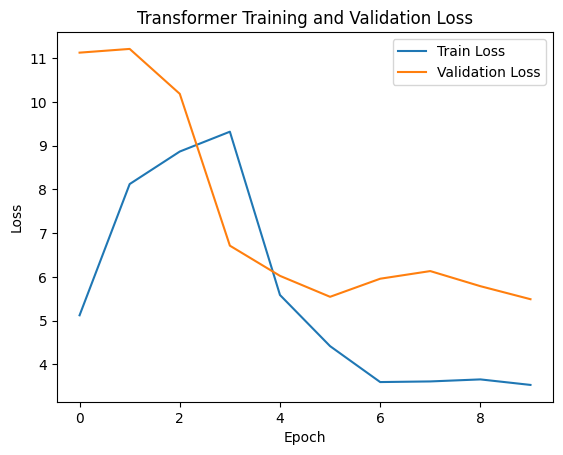

In [23]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(valid_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Transformer Training and Validation Loss")
plt.show()
